In [1]:
from dataclasses import dataclass, field
from Bio import SeqIO
import pandas as pd
import logomaker as lm
import matplotlib.pyplot as plt

In [2]:
@dataclass
class Seq:

    fasta: str
    dataframe: object = field(default=object, init=False, repr=False)

    def _dataframe(self):
        df = {}
        for i in SeqIO.parse(self.fasta, "fasta").records:
            df[i.name] = str(i._seq)
        self.dataframe = pd.DataFrame(df.values(), index=df.keys(), columns=['sequence'])
    
    def __post_init__(self):
        self._dataframe()

In [3]:
seq = Seq(fasta="sequences.fasta")
df = seq.dataframe
df

,sequence
alfa,LFVTMELDND
beta,LFVTMEVDND
gamma,VFVTMEVDND
delta,IYVVIEVDND
epsilon,LFVTMELDND
lambda,LFVTMEVDND


In [4]:
counts = lm.alignment_to_matrix(seq.dataframe["sequence"].to_list())
counts.index += 1
counts

,D,E,F,I,L,M,N,T,V,Y
pos,,,,,,,,,,
1,0,0,0,1,4,0,0,0,1,0
2,0,0,5,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,6,0
4,0,0,0,0,0,0,0,5,1,0
5,0,0,0,1,0,5,0,0,0,0
6,0,6,0,0,0,0,0,0,0,0
7,0,0,0,0,2,0,0,0,4,0
8,6,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,6,0,0,0


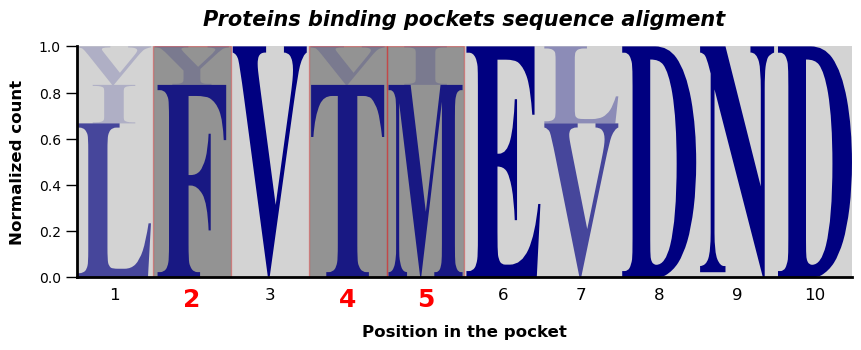

Consensus sequence: LFVTMEVDND


In [5]:
normalized_mat = lm.transform_matrix(counts, normalize_values=True)

logo = lm.Logo(normalized_mat,
        fade_probabilities=True,
        stack_order='small_on_top',
        font_name='Times New Roman',
        figsize=(10, 3),
        color_scheme="navy")

ax = logo.ax
ax.set_facecolor("lightgrey")
ax.set_xticks(counts.index)
ax.tick_params(axis="x", color="white", labelsize=12)
ax.tick_params(axis="y", width=1, length=8, direction="out", labelsize=10)

ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_title("Proteins binding pockets sequence aligment", fontdict=dict(fontweight="bold", fontsize=15, fontstyle="italic"), pad=15)
ax.set_xlabel("Position in the pocket", fontdict=dict(fontweight="bold", fontsize=12), labelpad=10)
ax.set_ylabel("Normalized count", fontdict=dict(fontweight="bold", fontsize=12), labelpad=10)

# Highlighting
positions = [2, 4, 5]
for i in positions:
        logo.highlight_position(i , color='black', alpha=0.3, edgecolor='red')
        ax.get_xticklabels()[i - 1].set_fontweight("bold")
        ax.get_xticklabels()[i - 1].set_color("red")
        ax.get_xticklabels()[i - 1].set_size(18)

plt.show()

# Consensus
consensus = []
for i in range(len(counts.index)):
    consensus.append(counts.iloc[i].idxmax())
consensus = "".join(consensus)
print(f"Consensus sequence: {consensus}")